In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, Sampler
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import pandas as pd
import numpy as np
import re, gc, os

torch.cuda.empty_cache()
gc.collect()
print(f"GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

GPU: 0.00 GB


In [2]:
# Fix Seed 
import random, os

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Seed fixed: {seed}")

SEED = 567
set_seed(SEED)

Seed fixed: 567


## Load Data

In [3]:
train_df = pd.read_csv("/kaggle/input/datasets/hoangnguyenhuy04/matres/train.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/hoangnguyenhuy04/matres/test.csv")

# lọc VAGUE trên test
test_df = test_df[test_df["label"] != "VAGUE"].reset_index(drop=True)

# Chia train → train + val
train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df["label"]
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print("\nTrain label distribution:")
print(train_df["label"].value_counts())
print("\nVal label distribution:")
print(val_df["label"].value_counts())
print("\nTest label distribution:")
print(test_df["label"].value_counts())

Train: 10404, Val: 1836, Test: 709

Train label distribution:
label
BEFORE    5257
AFTER     3614
VAGUE     1189
EQUAL      344
Name: count, dtype: int64

Val label distribution:
label
BEFORE    927
AFTER     638
VAGUE     210
EQUAL      61
Name: count, dtype: int64

Test label distribution:
label
BEFORE    413
AFTER     265
EQUAL      31
Name: count, dtype: int64


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10404 entries, 0 to 10403
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   entity1_id     10404 non-null  int64 
 1   entity2_id     10404 non-null  int64 
 2   entity1_start  10404 non-null  int64 
 3   entity2_start  10404 non-null  int64 
 4   entity1_end    10404 non-null  int64 
 5   entity2_end    10404 non-null  int64 
 6   entity1_text   10404 non-null  object
 7   entity2_text   10404 non-null  object
 8   document_id    10404 non-null  object
 9   text           10404 non-null  object
 10  label          10404 non-null  object
dtypes: int64(6), object(5)
memory usage: 894.2+ KB


In [5]:
train_df.head(5)

,entity1_id,entity2_id,entity1_start,entity2_start,entity1_end,entity2_end,entity1_text,entity2_text,document_id,text,label
0,1406,1414,126,377,134,387,affected,positioned,wsj_0586,A senior dealer with Warburg Securities noted ...,BEFORE
1,27,31,24,413,27,420,was,opposed,NYT19981026.0446,"Goldstein , who said it was `` thoroughly , th...",BEFORE
2,589,595,72,224,82,233,complained,delivered,PRI19980303.2000.2550,But opponents said the school might be a targe...,BEFORE
3,90,97,75,126,79,131,said,works,NYT19981025.0216,`` The only people that are left are the hard-...,AFTER
4,22,27,12,322,17,326,built,said,NYT20000329.0359,"As pressure built in this city , the home of a...",BEFORE


In [6]:
def insert_tags_fast(text_chunk, s1, e1, s2, e2):
    insertions = [(s1, "<e1>"), (e1, "</e1>"), (s2, "<e2>"), (e2, "</e2>")]
    insertions.sort(key=lambda x: x[0], reverse=True)
    text_list = list(text_chunk)
    for pos, tag in insertions:
        if pos == -1:
            continue
        pos = max(0, min(len(text_list), pos))
        text_list.insert(pos, tag)
    return "".join(text_list)


def find_boundary(text, idx, direction="left"):
    limit = 50
    if direction == "left":
        start = max(0, idx - limit)
        sub = text[start:idx]
        matches = list(re.finditer(r"[\s\.]", sub))
        return start + matches[-1].end() if matches else idx
    else:
        end = min(len(text), idx + limit)
        sub = text[idx:end]
        matches = list(re.finditer(r"[\s\.]", sub))
        return idx + matches[0].start() if matches else idx


def create_chunk(full_text, s1, e1, s2, e2, max_len=256):
    span_start = min(s1, s2)
    span_end   = max(e1, e2)
    dist       = span_end - span_start
    max_char_len = (max_len - 10) * 3

    if dist > max_char_len:
        pad = 50
        c1_s = max(0, s1 - pad); c1_e = min(len(full_text), e1 + pad)
        c2_s = max(0, s2 - pad); c2_e = min(len(full_text), e2 + pad)
        chunk1 = insert_tags_fast(full_text[c1_s:c1_e], s1-c1_s, e1-c1_s, -1, -1)
        chunk2 = insert_tags_fast(full_text[c2_s:c2_e], -1, -1, s2-c2_s, e2-c2_s)
        return chunk1 + " [SEP] " + chunk2

    remaining_chars = max_char_len - dist
    padding     = int(remaining_chars / 2)
    raw_start   = max(0, span_start - padding)
    raw_end     = min(len(full_text), span_end + padding)
    final_start = find_boundary(full_text, raw_start, "left")
    final_end   = find_boundary(full_text, raw_end,   "right")
    chunk_text  = full_text[final_start:final_end]
    return insert_tags_fast(
        chunk_text,
        s1 - final_start, e1 - final_start,
        s2 - final_start, e2 - final_start,
    )


def run_preprocessing(df, max_len=256):
    tqdm.pandas(desc="Processing")
    df["processed_text"] = df.progress_apply(
        lambda row: create_chunk(
            row["text"],
            row["entity1_start"], row["entity1_end"],
            row["entity2_start"], row["entity2_end"],
            max_len=max_len,
        ),
        axis=1,
    )
    return df

print("Preprocessing Train...")
train_df = run_preprocessing(train_df)
print("Preprocessing Val...")
val_df = run_preprocessing(val_df)
print("Preprocessing Test...")
test_df  = run_preprocessing(test_df)

Preprocessing Train...


Processing: 100%|██████████| 10404/10404 [00:00<00:00, 46777.63it/s]


Preprocessing Val...


Processing: 100%|██████████| 1836/1836 [00:00<00:00, 46721.00it/s]


Preprocessing Test...


Processing: 100%|██████████| 709/709 [00:00<00:00, 43296.91it/s]


In [7]:
train_df.head(5)

,entity1_id,entity2_id,entity1_start,entity2_start,entity1_end,entity2_end,entity1_text,entity2_text,document_id,text,label,processed_text
0,1406,1414,126,377,134,387,affected,positioned,wsj_0586,A senior dealer with Warburg Securities noted ...,BEFORE,A senior dealer with Warburg Securities noted ...
1,27,31,24,413,27,420,was,opposed,NYT19981026.0446,"Goldstein , who said it was `` thoroughly , th...",BEFORE,"Goldstein , who said it <e1>was</e1> `` thorou..."
2,589,595,72,224,82,233,complained,delivered,PRI19980303.2000.2550,But opponents said the school might be a targe...,BEFORE,But opponents said the school might be a targe...
3,90,97,75,126,79,131,said,works,NYT19981025.0216,`` The only people that are left are the hard-...,AFTER,`` The only people that are left are the hard-...
4,22,27,12,322,17,326,built,said,NYT20000329.0359,"As pressure built in this city , the home of a...",BEFORE,"As pressure <e1>built</e1> in this city , the ..."


In [8]:
class MatresDataset(Dataset):
    LABEL_MAP = {"BEFORE": 0, "AFTER": 1, "EQUAL": 2, "VAGUE": 3}

    def __init__(self, dataframe, tokenizer, max_length=256):
        self.data       = dataframe.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row     = self.data.iloc[idx]
        encoded = self.tokenizer(
            row["processed_text"],
            add_special_tokens=True,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        input_ids      = encoded["input_ids"].flatten()
        attention_mask = encoded["attention_mask"].flatten()
        token_type_ids = encoded.get(
            "token_type_ids", torch.zeros_like(input_ids)
        ).flatten()

        e1_id = self.tokenizer.convert_tokens_to_ids("<e1>")
        e2_id = self.tokenizer.convert_tokens_to_ids("<e2>")

        def find_pos(ids, target_id):
            matches = (ids == target_id).nonzero(as_tuple=False)
            if len(matches) > 0:
                return torch.clamp(matches[0][0], 0, self.max_length - 1)
            return torch.tensor(0)

        e1_pos = find_pos(input_ids, e1_id)
        e2_pos = find_pos(input_ids, e2_id)

        return {
            "input_ids":      input_ids,
            "attention_mask": attention_mask,
            "token_type_ids": token_type_ids,
            "labels":         torch.tensor(self.LABEL_MAP.get(row["label"], -1), dtype=torch.long),
            "e1_pos":         e1_pos,
            "e2_pos":         e2_pos,
            "event1_id":      f"{row['document_id']}_{row['entity1_id']}",
            "event2_id":      f"{row['document_id']}_{row['entity2_id']}",
            "document_id":    row["document_id"],
        }


class SmartBatchSampler(Sampler):
    """Gom các cặp trong cùng document vào cùng batch → consistency loss có nhiều signal hơn."""

    def __init__(self, dataframe, batch_size):
        self.batch_size  = batch_size
        self.doc_groups  = {}
        for idx, row in dataframe.iterrows():
            self.doc_groups.setdefault(row["document_id"], []).append(idx)
        self.doc_ids = list(self.doc_groups.keys())

    def __iter__(self):
        np.random.shuffle(self.doc_ids)
        batch = []
        for doc_id in self.doc_ids:
            idxs = list(self.doc_groups[doc_id])
            np.random.shuffle(idxs)
            batch.extend(idxs)
            while len(batch) >= self.batch_size:
                yield batch[: self.batch_size]
                batch = batch[self.batch_size :]
        if batch:
            yield batch

    def __len__(self):
        total = sum(len(v) for v in self.doc_groups.values())
        return (total + self.batch_size - 1) // self.batch_size


def collate_fn(batch):
    return {
        "input_ids":      torch.stack([x["input_ids"]      for x in batch]),
        "attention_mask": torch.stack([x["attention_mask"] for x in batch]),
        "token_type_ids": torch.stack([x["token_type_ids"] for x in batch]),
        "labels":         torch.stack([x["labels"]         for x in batch]),
        "e1_pos":         torch.stack([x["e1_pos"]         for x in batch]),
        "e2_pos":         torch.stack([x["e2_pos"]         for x in batch]),
        "event1_id":      [x["event1_id"]   for x in batch],
        "event2_id":      [x["event2_id"]   for x in batch],
        "document_id":    [x["document_id"] for x in batch],
    }


# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
tokenizer.add_special_tokens(
    {"additional_special_tokens": ["<e1>", "</e1>", "<e2>", "</e2>"]}
)


BATCH_SIZE = 32

train_dataset = MatresDataset(train_df, tokenizer)
val_dataset   = MatresDataset(val_df,   tokenizer)
test_dataset  = MatresDataset(test_df,   tokenizer)

train_sampler = SmartBatchSampler(train_df, BATCH_SIZE)

train_loader = DataLoader(train_dataset, batch_sampler=train_sampler,
                          num_workers=0, pin_memory=False, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False, collate_fn=collate_fn)

print(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} batches")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 326 batches | Val: 58 batches


In [9]:
class GeoTREModel(nn.Module):
    def __init__(self, model_name="roberta-base", num_classes=5,
                 hidden=256, dropout=0.2, topk=5):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size  = self.encoder.config.hidden_size
        self.topk    = topk

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_size, num_heads=8,
            dropout=dropout, batch_first=True,
        )
        self.proj = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.geo_head = nn.Sequential(
            nn.Linear(hidden_size, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2),
        )

        # Semantic classification head
        self.cls_head = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

        # Phân biệt VAGUE
        self.vague_head = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2),  # 0=non-VAGUE, 1=VAGUE
        )

        # Tolerance cho EQUAL
        self.simul_threshold = nn.Parameter(torch.tensor(-2.0))
        # Temperature cho geo logits
        self.geo_temp = nn.Parameter(torch.tensor(0.0))

    def _event_repr(self, hidden_states, pos_idx, attention_mask=None):
        B = hidden_states.size(0)
        h = hidden_states[torch.arange(B), pos_idx]
        query = h.unsqueeze(1)
        key_padding_mask = (attention_mask == 0) if attention_mask is not None else None
        _, attn_weights = self.cross_attn(
            query=query, key=hidden_states, value=hidden_states,
            key_padding_mask=key_padding_mask,
        )
        weights = attn_weights.squeeze(1)
        topk_weights, topk_idx = weights.topk(self.topk, dim=-1)
        topk_weights = topk_weights / (topk_weights.sum(dim=-1, keepdim=True) + 1e-9)
        topk_vectors = hidden_states[
            torch.arange(B).unsqueeze(1).expand_as(topk_idx), topk_idx
        ]
        h_context = (topk_weights.unsqueeze(-1) * topk_vectors).sum(dim=1)
        h_rich = self.proj(torch.cat([h, h_context], dim=-1))
        out = self.geo_head(h_rich)
        s = out[:, 0]
        #  min duration 0.05 
        e = s + F.softplus(out[:, 1]) + 0.05
        return s, e, h_rich

    def _compute_geo_logits(self, s1, e1, s2, e2):
        """
        Tính logits hình học cho MATRES (3 classes).
        
        3 quan hệ:
            BEFORE: E1 trước E2 (gap > 0)
            AFTER:  E2 trước E1 (gap > 0)
            EQUAL:  E1 ≈ E2 (gần trùng nhau)
        """
        # BEFORE: E1 kết thúc trước E2 bắt đầu 
        logit_before = s2 - e1

        # AFTER: E2 kết thúc trước E1 bắt đầu 
        logit_after = s1 - e2

        # EQUAL: E1 ≈ E2 (cả start và end gần nhau) 
        tol  = F.softplus(self.simul_threshold)
        dist = torch.abs(s2 - s1) + torch.abs(e1 - e2)
        logit_equal = 2 * tol - dist

        logits = torch.stack([
            logit_before,
            logit_after,
            logit_equal,
        ], dim=1)

        temp = F.softplus(self.geo_temp) + 0.1
        return logits / temp

    def forward(self, input_ids, attention_mask, e1_pos, e2_pos, token_type_ids=None):
        H = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        ).last_hidden_state

        s1, e1, h1 = self._event_repr(H, e1_pos, attention_mask)
        s2, e2, h2 = self._event_repr(H, e2_pos, attention_mask)

        logits_sem   = self.cls_head(torch.cat([h1, h2], dim=1))
        logits_geo   = self._compute_geo_logits(s1, e1, s2, e2)
        logits_vague = self.vague_head(torch.cat([h1, h2], dim=1))  

        return s1, e1, s2, e2, logits_sem, logits_geo, logits_vague  

In [10]:
class MATRESLoss(nn.Module):
    """
    total = CE(sem)                           (semantic classification)
          + λ_gce   * CE(geo)                (Allen's geometry → coordinate learning)
          + λ_con   * consistency_loss        (same event = same coordinates)
          + λ_align * KL_sym(sem, geo)        (two branches agree)
          + λ_vague * vague_separation_loss   (VAGUE vs non-VAGUE)
    """

    def __init__(self, lambda_con=0.1,
                 lambda_gce=0.5, lambda_align=0.1, lambda_vague=0.1):  
        super().__init__()
        self.register_buffer(
            "class_weights", torch.tensor([1.0, 1.4, 8.0, 0.1])  
        )
        self.lambda_con   = lambda_con
        self.lambda_gce   = lambda_gce
        self.lambda_align = lambda_align
        self.lambda_vague = lambda_vague
        print(f"[MATRESLoss] CE_sem + {lambda_con}*con "
              f"+ {lambda_gce}*CE_geo + {lambda_align}*KL_align + {lambda_vague}*vague")

    def _consistency_loss(self, s1, e1, s2, e2, event1_ids, event2_ids):
        event_s = {}; event_e = {}
        for i in range(len(s1)):
            event_s.setdefault(event1_ids[i], []).append(s1[i])
            event_s.setdefault(event2_ids[i], []).append(s2[i])
            event_e.setdefault(event1_ids[i], []).append(e1[i])
            event_e.setdefault(event2_ids[i], []).append(e2[i])
        c_losses = []
        for eid in event_s:
            if len(event_s[eid]) < 2: continue
            s_t = torch.stack(event_s[eid]); e_t = torch.stack(event_e[eid])
            c_losses.append(((s_t - s_t.mean().detach())**2).mean() +
                            ((e_t - e_t.mean().detach())**2).mean())
        if not c_losses:
            return torch.tensor(0.0, device=s1.device)
        return torch.stack(c_losses).mean()

    def _vague_separation_loss(self, logits_vague, labels):
        """Binary loss: phân biệt VAGUE (1) vs non-VAGUE (0)"""
        binary_labels = (labels == VAGUE_IDX).long()
        return F.cross_entropy(logits_vague, binary_labels)

    def _alignment_loss(self, logits_sem, logits_geo, eps=1e-8):
        """
        Symmetric KL giữa 2 predicted distributions.
        """
        p_sem = F.softmax(logits_sem[:, :3], dim=-1).clamp(min=eps) 
        p_geo = F.softmax(logits_geo,        dim=-1).clamp(min=eps)

        kl_fwd = (p_sem * (p_sem.log() - p_geo.log())).sum(-1).mean()
        kl_bwd = (p_geo * (p_geo.log() - p_sem.log())).sum(-1).mean()

        return 0.5 * (kl_fwd + kl_bwd)

    def forward(self, s1, e1, s2, e2, labels, logits_sem, logits_geo=None,
                logits_vague=None, event1_ids=None, event2_ids=None): 

        w = self.class_weights.to(logits_sem.device)

        # Branch semantic
        ce_sem = F.cross_entropy(logits_sem, labels, weight=w)

        # Consistency
        con_loss = self._consistency_loss(s1, e1, s2, e2, event1_ids, event2_ids) \
                   if (self.lambda_con != 0 and event1_ids is not None) \
                   else torch.tensor(0.0, device=s1.device)

        # Branch geometric CE + Alignment
        ce_geo   = torch.tensor(0.0, device=logits_sem.device)
        aln_loss = torch.tensor(0.0, device=logits_sem.device)

        if logits_geo is not None:
            ce_geo   = F.cross_entropy(logits_geo, labels, weight=w[:3], ignore_index=VAGUE_IDX) 
            aln_loss = self._alignment_loss(logits_sem, logits_geo)

        # Vague separation loss
        vague_loss = self._vague_separation_loss(logits_vague, labels) \
                     if logits_vague is not None \
                     else torch.tensor(0.0, device=logits_sem.device)

        total = (ce_sem
                 + self.lambda_con   * con_loss
                 + self.lambda_gce   * ce_geo
                 + self.lambda_align * aln_loss
                 + self.lambda_vague * vague_loss)  # ← thêm

        return total, ce_sem, con_loss, ce_geo, aln_loss, vague_loss 

In [11]:
LABEL_NAMES = ["BEFORE", "AFTER", "EQUAL", "VAGUE"]
NUM_CLASSES  = 4
VAGUE_IDX    = 3
EVAL_LABELS  = list(range(3))

def train_epoch(model, loader, criterion, optimizer, device, scheduler=None):
    model.train()
    total = ce_sum = con_sum = gce_sum = aln_sum = vag_sum = 0.0 

    bar = tqdm(loader, desc="  Train")
    for batch in bar:
        input_ids      = batch["input_ids"].to(device)
        mask           = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        e1_pos         = batch["e1_pos"].to(device)
        e2_pos         = batch["e2_pos"].to(device)
        labels         = batch["labels"].to(device)
        ev1_ids        = batch["event1_id"]
        ev2_ids        = batch["event2_id"]

        optimizer.zero_grad()
        s1, e1, s2, e2, logits_sem, logits_geo, logits_vague = model(
            input_ids, mask, e1_pos, e2_pos, token_type_ids
        )

        loss, ce, con, gce, aln, vag = criterion( 
            s1, e1, s2, e2, labels,
            logits_sem, logits_geo, logits_vague, 
            ev1_ids, ev2_ids
        )
        if loss.dim() > 0: loss = loss.mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler: scheduler.step()

        total   += loss.item()
        ce_sum  += ce.item()
        con_sum += con.item()
        gce_sum += gce.item()
        aln_sum += aln.item()
        vag_sum += vag.item()  # ← thêm

        bar.set_postfix(loss=f"{loss.item():.3f}", ce=f"{ce.item():.3f}",
                        gce=f"{gce.item():.3f}", vag=f"{vag.item():.3f}")

    n = len(loader)
    return total/n, ce_sum/n, con_sum/n, gce_sum/n, aln_sum/n, vag_sum/n 


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc="  Val  "):
        input_ids      = batch["input_ids"].to(device)
        mask           = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        e1_pos         = batch["e1_pos"].to(device)
        e2_pos         = batch["e2_pos"].to(device)
        labels         = batch["labels"].to(device)

        s1, e1, s2, e2, logits_sem, logits_geo, logits_vague = model( 
            input_ids, mask, e1_pos, e2_pos, token_type_ids
        )
        loss, ce, con, gce, aln, vag = criterion(  # ← thêm
            s1, e1, s2, e2, labels, logits_sem, logits_geo, logits_vague
        )
        if loss.dim() > 0: loss = loss.mean()
        total += loss.item()

        # Quyết định cuối dùng logits_sem (branch chính)
        preds = logits_sem.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total / len(loader)
    acc      = accuracy_score(all_labels, all_preds)

    mask = np.array(all_labels) != VAGUE_IDX
    f1   = f1_score(np.array(all_labels)[mask], np.array(all_preds)[mask],
                    labels=EVAL_LABELS,
                    average="macro", zero_division=0)

    return avg_loss, acc, f1

In [12]:
if "model"     in dir(): del model
if "optimizer" in dir(): del optimizer
if "criterion" in dir(): del criterion
gc.collect(); torch.cuda.empty_cache()

EPOCHS       = 40
LR           = 2e-5
PATIENCE     = 5
SAVE_PATH    = "/kaggle/working/geotre_matres_latest_roberta_model_seed_567.pth"
LAMBDA_CON   = 0.1
LAMBDA_GCE   = 0.5
LAMBDA_ALIGN = 0.1
LAMBDA_VAGUE = 0.1  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GeoTREModel(model_name="roberta-base", num_classes=NUM_CLASSES)
model.encoder.resize_token_embeddings(len(tokenizer))

if torch.cuda.device_count() > 1:
    print(f"--> {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model.to(device)

criterion = MATRESLoss(
    lambda_con=LAMBDA_CON,
    lambda_gce=LAMBDA_GCE,
    lambda_align=LAMBDA_ALIGN,
    lambda_vague=LAMBDA_VAGUE, 
)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

from transformers import get_linear_schedule_with_warmup
total_steps  = len(train_loader) * EPOCHS
warmup_steps = total_steps // 10
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
print(f"Total steps: {total_steps} | Warmup steps: {warmup_steps}")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, 

--> 2 GPUs
[MATRESLoss] CE_sem + 0.1*con + 0.5*CE_geo + 0.1*KL_align + 0.1*vague
Total steps: 13040 | Warmup steps: 1304


In [13]:
best_f1           = 0.0
loss_patience_cnt = 0
prev_train_loss   = float("inf")

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    tr_loss, tr_ce, tr_con, tr_gce, tr_aln, tr_vag = train_epoch(  
        model, train_loader, criterion, optimizer, device, scheduler
    )

    val_loss, val_acc, val_f1 = eval_epoch(
        model, val_loader, criterion, device
    )

    print(f"  Train: total={tr_loss:.4f}  ce={tr_ce:.4f}  "
          f"con={tr_con:.4f}  "
          f"gce={tr_gce:.4f}  aln={tr_aln:.4f}  vag={tr_vag:.4f}")  
    print(f"  Val  : loss={val_loss:.4f}  acc={val_acc:.4f}  macro-F1={val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        core = model.module if isinstance(model, nn.DataParallel) else model
        torch.save(core.state_dict(), SAVE_PATH)
        print(f"  --> Saved! (best F1={best_f1:.4f})")

    if (prev_train_loss - tr_loss) < 0.01:
        loss_patience_cnt += 1
        print(f"   Patience {loss_patience_cnt}/{PATIENCE}")
        if loss_patience_cnt >= PATIENCE:
            print("Early stopping!")
            break
    else:
        loss_patience_cnt = 0

    prev_train_loss = tr_loss

print(f"\nBest Val Macro-F1: {best_f1:.4f}")


Epoch 1/40


  Val  : 100%|██████████| 58/58 [00:17<00:00,  3.34it/s]


  Train: total=1.9783  ce=1.2843  con=0.0922  gce=1.2305  aln=0.1828  vag=0.5123
  Val  : loss=1.6664  acc=0.5272  macro-F1=0.4010
  --> Saved! (best F1=0.4010)

Epoch 2/40


  Val  : 100%|██████████| 58/58 [00:17<00:00,  3.29it/s]


  Train: total=1.4723  ce=0.9514  con=0.0920  gce=0.9142  aln=0.1824  vag=0.3645
  Val  : loss=1.2289  acc=0.7418  macro-F1=0.5676
  --> Saved! (best F1=0.5676)

Epoch 3/40


...

  Train: total=0.0915  ce=0.0396  con=0.2233  gce=0.0398  aln=0.0307  vag=0.0660
  Val  : loss=2.0976  acc=0.7691  macro-F1=0.6475
   Patience 3/5

Epoch 31/40


  Val  : 100%|██████████| 58/58 [00:17<00:00,  3.33it/s]


  Train: total=0.0861  ce=0.0356  con=0.2194  gce=0.0393  aln=0.0305  vag=0.0591
  Val  : loss=2.1583  acc=0.7712  macro-F1=0.6401
   Patience 4/5

Epoch 32/40


  Val  : 100%|██████████| 58/58 [00:17<00:00,  3.31it/s]

  Train: total=0.0866  ce=0.0366  con=0.2135  gce=0.0400  aln=0.0300  vag=0.0565
  Val  : loss=2.1179  acc=0.7745  macro-F1=0.6440
   Patience 5/5
Early stopping!

Best Val Macro-F1: 0.6684


In [14]:
core = model.module if isinstance(model, nn.DataParallel) else model
core.load_state_dict(torch.load(SAVE_PATH))
model.to(device)
model.eval()

all_logits_sem_val, all_logits_geo_val, all_labels_val = [], [], []
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Val for alpha search"):
        input_ids      = batch["input_ids"].to(device)
        mask           = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        e1_pos         = batch["e1_pos"].to(device)
        e2_pos         = batch["e2_pos"].to(device)
        labels         = batch["labels"].to(device)

        s1, e1, s2, e2, logits_sem, logits_geo, logits_vague = model( 
            input_ids, mask, e1_pos, e2_pos, token_type_ids
        )
        all_logits_sem_val.append(logits_sem.cpu())
        all_logits_geo_val.append(logits_geo.cpu())
        all_labels_val.extend(labels.cpu().numpy())

prob_sem_val   = F.softmax(torch.cat(all_logits_sem_val), dim=-1)
prob_geo_val   = F.softmax(torch.cat(all_logits_geo_val), dim=-1)
all_labels_val = np.array(all_labels_val)

prob_geo_val_pad = F.pad(prob_geo_val, (0, 1), value=0.0)  

best_alpha, best_f1_val = 0.0, 0.0
for alpha in np.arange(0.0, 1.05, 0.05):
    prob_combined = alpha * prob_sem_val + (1 - alpha) * prob_geo_val_pad
    preds         = prob_combined.argmax(dim=-1).numpy()
    vague_mask    = all_labels_val != VAGUE_IDX  
    f1_val        = f1_score(all_labels_val[vague_mask], preds[vague_mask],
                             labels=EVAL_LABELS, average="micro", zero_division=0)
    if f1_val > best_f1_val:
        best_f1_val = f1_val
        best_alpha  = alpha

print(f"Best alpha (val): {best_alpha:.2f} | Val Micro-F1: {best_f1_val:.4f}")

Val for alpha search: 100%|██████████| 58/58 [00:17<00:00,  3.32it/s]


Best alpha (val): 1.00 | Val Micro-F1: 0.8574


Testing: 100%|██████████| 23/23 [00:06<00:00,  3.36it/s]


Dùng alpha từ val set: 1.00

  1. SEMANTIC Branch
  Micro-F1: 0.8161  |  Macro-F1: 0.6150
              precision    recall  f1-score   support

      BEFORE     0.9152    0.8620    0.8878       413
       AFTER     0.8366    0.8113    0.8238       265
       EQUAL     0.1017    0.1935    0.1333        31

   micro avg     0.8184    0.8138    0.8161       709
   macro avg     0.6178    0.6223    0.6150       709
weighted avg     0.8502    0.8138    0.8309       709


  2. GEOMETRIC Branch
  Micro-F1: 0.8166  |  Macro-F1: 0.6209
              precision    recall  f1-score   support

      BEFORE     0.9156    0.8668    0.8905       413
       AFTER     0.8327    0.8075    0.8199       265
       EQUAL     0.1148    0.2258    0.1522        31

    accuracy                         0.8166       709
   macro avg     0.6210    0.6334    0.6209       709
weighted avg     0.8496    0.8166    0.8319       709


  3. ENSEMBLE (α=1.00)
  Micro-F1: 0.8161  |  Macro-F1: 0.6150
              precisi

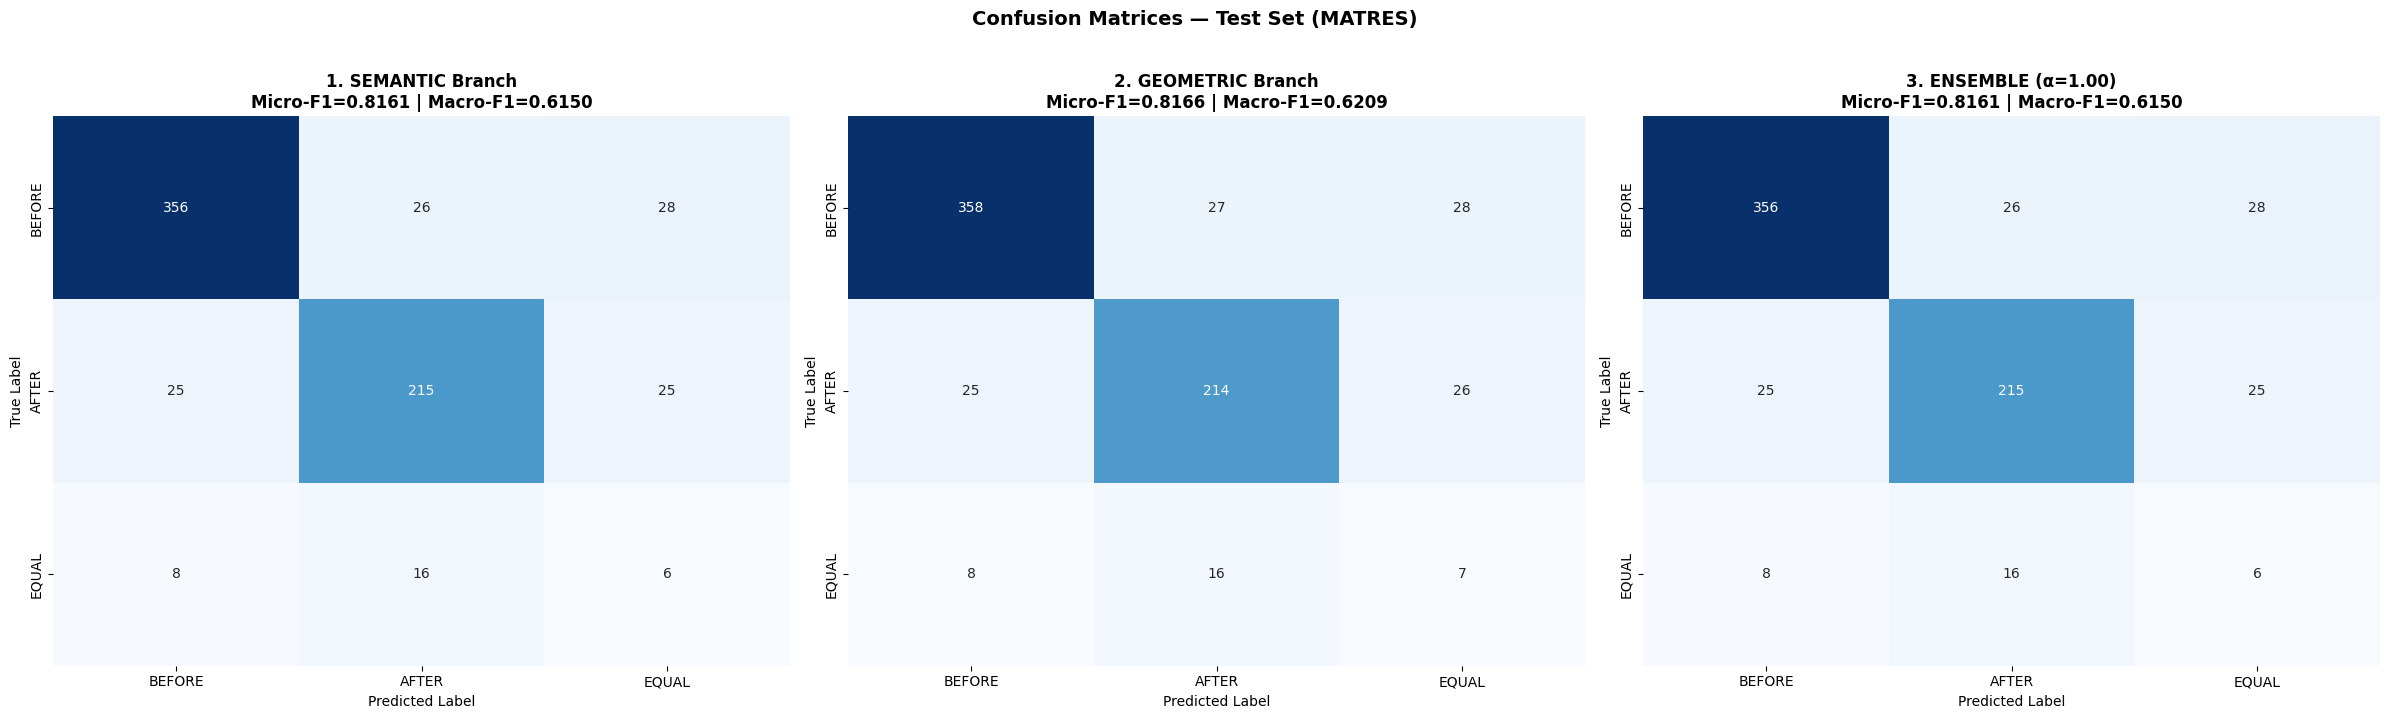


  SUMMARY — TEST SET
  Strategy                            |   Micro-F1 |   Macro-F1
  ------------------------------------+------------+-----------
  1. SEMANTIC Branch                  |     0.8161 |     0.6150
  2. GEOMETRIC Branch                 |     0.8166 |     0.6209
  3. ENSEMBLE (α=1.00)                |     0.8161 |     0.6150


In [15]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

# Load best model
core = model.module if isinstance(model, nn.DataParallel) else model
core.load_state_dict(torch.load(SAVE_PATH))
model.to(device)
model.eval()

# Collect tất cả logits
all_logits_sem = []
all_logits_geo = []
all_labels     = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids      = batch["input_ids"].to(device)
        mask           = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        e1_pos         = batch["e1_pos"].to(device)
        e2_pos         = batch["e2_pos"].to(device)
        labels         = batch["labels"].to(device)

        s1, e1, s2, e2, logits_sem, logits_geo, logits_vague = model(  # ← thêm
            input_ids, mask, e1_pos, e2_pos, token_type_ids
        )
        all_logits_sem.append(logits_sem.cpu())
        all_logits_geo.append(logits_geo.cpu())
        all_labels.extend(labels.cpu().numpy())

all_logits_sem = torch.cat(all_logits_sem, dim=0)
all_logits_geo = torch.cat(all_logits_geo, dim=0)
all_labels     = np.array(all_labels)

prob_sem = F.softmax(all_logits_sem, dim=-1)
prob_geo = F.softmax(all_logits_geo, dim=-1)

print(f"Dùng alpha từ val set: {best_alpha:.2f}")

# TÍNH PREDICTIONS CHO CẢ 3 NHÁNH
preds_sem    = all_logits_sem.argmax(dim=-1).numpy()
preds_geo    = all_logits_geo.argmax(dim=-1).numpy()
prob_geo_pad = F.pad(prob_geo, (0, 1), value=0.0)
prob_best    = best_alpha * prob_sem + (1 - best_alpha) * prob_geo_pad
preds_ens    = prob_best.argmax(dim=-1).numpy()

strategies = [
    ("1. SEMANTIC Branch",                preds_sem),
    ("2. GEOMETRIC Branch",               preds_geo),
    (f"3. ENSEMBLE (α={best_alpha:.2f})", preds_ens),
]

# CLASSIFICATION REPORT
for title, preds in strategies:
    micro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="macro", zero_division=0)

    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"  Micro-F1: {micro_f1:.4f}  |  Macro-F1: {macro_f1:.4f}")
    print(f"{'='*60}")
    print(classification_report(
        all_labels, preds,
        target_names=LABEL_NAMES[:3], 
        labels=EVAL_LABELS,
        zero_division=0, digits=4,
    ))

# CONFUSION MATRIX
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, (title, preds) in zip(axes, strategies):
    micro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="macro", zero_division=0)

    cm = confusion_matrix(all_labels, preds, labels=EVAL_LABELS)

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=LABEL_NAMES[:3], yticklabels=LABEL_NAMES[:3],
        ax=ax, cbar=False,
    )
    ax.set_title(f"{title}\nMicro-F1={micro_f1:.4f} | Macro-F1={macro_f1:.4f}",
                 fontsize=12, fontweight='bold')
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

plt.suptitle("Confusion Matrices — Test Set (MATRES)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# BẢNG TỔNG KẾT
print("\n" + "="*60)
print("  SUMMARY — TEST SET")
print("="*60)
print(f"  {'Strategy':<35} | {'Micro-F1':>10} | {'Macro-F1':>10}")
print(f"  {'-'*35}-+-{'-'*10}-+-{'-'*10}")

for title, preds in strategies:
    micro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="macro", zero_division=0)
    print(f"  {title:<35} | {micro_f1:>10.4f} | {macro_f1:>10.4f}")

print("="*60)